<a href="https://colab.research.google.com/github/bforoura/GENAI26/blob/main/Module5/ReACT_weather_app_local.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ReAct Weather Agent**



## **0. Local Environment and Requirements**

* To run this code successfully on your laptop, ensure you have the following setup:

* **Ollama Server** running locally with the models (qwen2.5-coder:7b, etc.) already pulled.

* Python Runtime version 3.10 through 3.13.

* Install the following dependencies via terminal:
---
  * **pip install streamlit langchain-ollama langchain-classic requests**
---
  * **streamlit**: The frontend web framework
  * **langchain-ollama**: Bridge between LangChain and local Ollama models.
  * **langchain-classic**: Contains **AgentExecutor**
  * **requests**: Standard library for the weather API calls.

## **1. Define the Weather Tool**

* This section contains the core logic for data retrieval to fetch real-time weather information from the **Open-Meteo API.**

* It uses the **@tool decorator** to convert a standard Python function into an "**agent-ready**" tool.

* **Geocoding** translates a city name string into numeric **Latitude and Longitude** coordinates.

* **Weather Fetching** uses those coordinates to request current temperature and wind speed.

* A formatted string containing the weather details, or an error message if the location cannot be found.

In [ ]:
######################################################################################
# Define the Weather Tool
######################################################################################
@tool
def get_weather(location: str) -> str:
    """
    Fetches the current weather for a given city name.
    It first geocodes the city to coordinates and then retrieves the weather data.
    """
    try:
        # Step 1: Geocoding - Convert city name to lat/long
        geo_url = f"https://geocoding-api.open-meteo.com/v1/search?name={location}&count=1&language=en&format=json"
        geo_res = requests.get(geo_url, timeout=10).json()

        if not geo_res.get("results"):
            return f"Could not find coordinates for {location}. Please check the spelling."

        lat = geo_res["results"][0]["latitude"]
        lon = geo_res["results"][0]["longitude"]
        name = geo_res["results"][0]["name"]

        # Step 2: Get weather data
        weather_url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&current_weather=true"
        weather_res = requests.get(weather_url, timeout=10).json()

        current = weather_res.get("current_weather")
        if not current:
            return "Weather data is currently unavailable."

        temp = current["temperature"]
        wind = current["windspeed"]

        return f"The current weather in {name} is {temp} degrees Celsius with a wind speed of {wind} km/h."

    except Exception as e:
        return f"Error retrieving weather: {str(e)}"

## **2. Setup the Streamlit UI**

* This section creates the user interface (UI) and sidebar configuration to run on **your local machine** (not in Colab).

* It sets the layout to "wide" for better readability of the chat interface.

* **Sidebar** includes a dropdown menu to switch between different local models hosted on Ollama.

* It provides  instructions to the user regarding supported capabilities and the lack of API key requirements.

In [ ]:
######################################################################################
# Setup the Streamlit UI
######################################################################################


st.set_page_config(page_title="Weather ReAct Agent", layout="wide")
st.title("Local Weather Agent")
st.caption("Using Ollama and Open-Meteo API")

with st.sidebar:
    model_choice = st.selectbox(
        "Select Model",
        ["qwen2.5-coder:7b", "qwen2.5-coder:3b", "llama3.2:3b", "deepseek-r1:1.5b"]
    )
    st.info("Ask about the weather in any city. No API key required.")



## **3. Initialize the Agent**


* Here, the connection between the application and the local inference engine is established.

* LLM Connection uses **ChatOllama** to connect to the specific model chosen in the sidebar. The temperature is set to 0 to ensure deterministic, consistent reasoning.

* It places the** get_weather** function into a list, making it available for the agent to use during the **ReAct loop**.

In [ ]:
######################################################################################
# Initialize the Agent
######################################################################################

llm = ChatOllama(model=model_choice, temperature=0)
tools = [get_weather]



## **4. Standard ReAct Prompt**

* This is the "**brain**" of the agent's logic, defined as a **PromptTemplate**.

* It forces the LLM to follow a specific thought process: **Question → Thought → Action → Action Input → Observation**

* It explicitly lists the available tools and the exact syntax the model must use to trigger them.

* The **{agent_scratchpad}** variable is a dynamic placeholder where the agent records its intermediate thoughts and tool results before reaching a final answer.

In [ ]:
######################################################################################
# Standard ReAct Prompt
######################################################################################

template = """Answer the following questions as best you can. You have access to the following tools:

{tools}

Use the following format:

Question: the input question you must answer
Thought: you should always think about what to do
Action: the action to take, should be one of [{tool_names}]
Action Input: the input to the action
Observation: the result of the action
... (this Thought/Action/Action Input/Observation can repeat N times)
Thought: I now know the final answer
Final Answer: the final answer to the original input question

Begin!

Question: {input}
Thought:{agent_scratchpad}"""

prompt = PromptTemplate.from_template(template)


## **5. Create the Agent Logic**


* This section compiles the LLM, the tools, and the prompt into a single agent object.

* **create_react_agent** is used to create the "**plan**" that the agent will follow.

* It essentially maps the prompt template onto the specific model's capabilities.

In [ ]:
######################################################################################
# Create the agent logic
######################################################################################

agent = create_react_agent(llm, tools, prompt)



## **6. Create the Executor**

* The **AgentExecutor** is the runtime environment that manages the loop.

* It sends the user's question to the agent, intercepts the "**Action**" request, physically runs the Python weather tool, and feeds the "**Observation**" back to the agent.

* **handle_parsing_errors=True** is enabled to ensure the app doesn't crash if the local model makes a slight formatting mistake in its reasoning block.

In [ ]:
######################################################################################
# Create the executor
######################################################################################

agent_executor = AgentExecutor(
    agent=agent,
    tools=tools,
    verbose=True,
    handle_parsing_errors=True
)



## **7. Chat Interface**

* The final section manages the session state and the visual chat bubble interaction.

* **Session State** keeps a history of **st.session_state.messages** so the conversation persists as the user continues to ask questions.

* It aptures user text, triggers the agent_executor with a loading spinner, and displays the final synthesized answer from the LLM.

In [ ]:
######################################################################################
# Chat Interface
######################################################################################

if "messages" not in st.session_state:
    st.session_state.messages = []

for message in st.session_state.messages:
    with st.chat_message(message["role"]):
        st.markdown(message["content"])

if user_input := st.chat_input("What is the weather in Tokyo?"):
    st.session_state.messages.append({"role": "user", "content": user_input})
    with st.chat_message("user"):
        st.markdown(user_input)

    with st.chat_message("assistant"):
        with st.spinner("Consulting weather stations..."):
            try:
                response = agent_executor.invoke({"input": user_input})
                final_answer = response["output"]
            except Exception as e:
                final_answer = f"An error occurred during agent execution: {str(e)}"

            st.markdown(final_answer)
            st.session_state.messages.append({"role": "assistant", "content": final_answer})


# **How to Run the Code**


* Ensure the **Ollama** application is open and running in your system tray or terminal.


* Open your terminal and download the required model if you haven't already:

   `  ollama pull qwen2.5-coder:7b`


* Open your terminal and cd into the folder containing your file:

* Run the script using the **Streamlit** command:

    `streamlit run react_weather_app.py`

* Your default web browser will open to http://localhost:8501. You can now select your model from the sidebar and ask about the weather in any city.


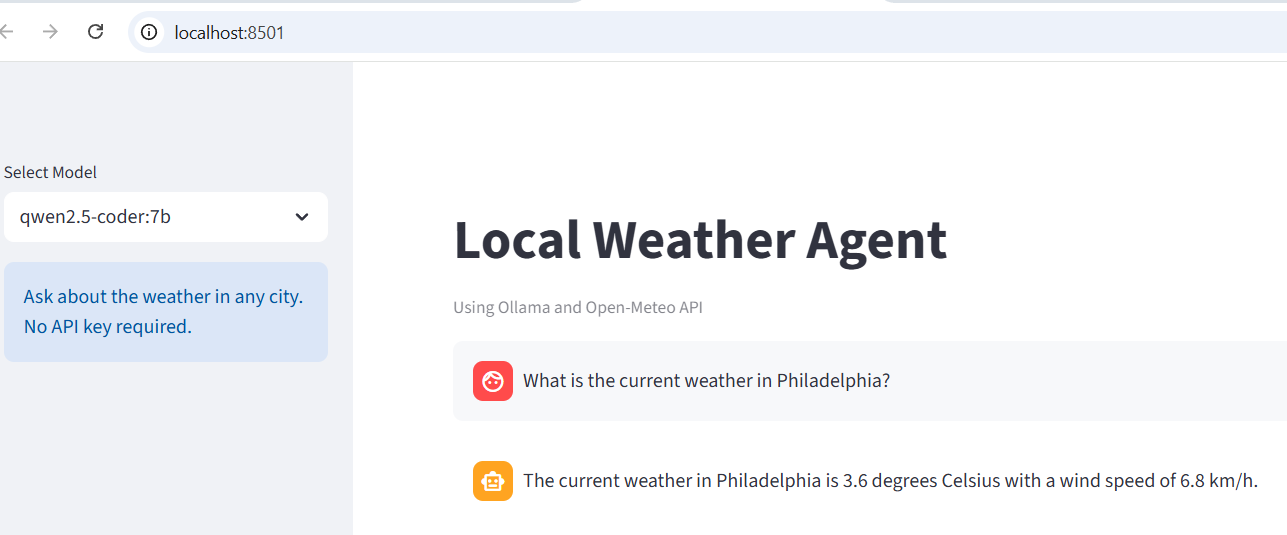